<a href="https://colab.research.google.com/github/swastikkmaurya/EDP_Project/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Data Inspection

In [2]:
# Dataset
df = pd.read_csv('India Stocks Data.csv')
df

,Company Name,Ticker,Price (INR)
0,Reliance Industries Ltd,RELIANCE,1292.67
1,Tata Consultancy Services Ltd,TCS,3347.91
2,HDFC Bank Ltd,HDFCBANK,1707.89
3,ICICI Bank Ltd,ICICIBANK,1231.81
4,Infosys Ltd,INFY,1582.12
5,State Bank of India,SBIN,818.19
6,Phantom Corp Ltd,PHANTOM,NaN
7,Bharti Airtel Ltd,BHARTIARTL,1921.88
8,ITC Ltd,ITC,425.01
9,Kotak Mahindra Bank Ltd,KOTAKBANK,1972.37


In [3]:
# Total number of elements in Dataset
df.size

1584

In [4]:
df.info()  # Summary of DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Company Name  524 non-null    object
 1   Ticker        525 non-null    object
 2   Price (INR)   521 non-null    object
dtypes: object(3)
memory usage: 12.5+ KB


In [5]:
df.shape  # Dimensions of DataFrame

(528, 3)

In [6]:
df.describe()  # Descriptive Statistics of DataFrame

,Company Name,Ticker,Price (INR)
count,524,525,521
unique,490,490,504
top,ITC Ltd,ITC,456.7
freq,6,7,5


In [7]:
df.head()  # First 5 rows of DataFrame

,Company Name,Ticker,Price (INR)
0,Reliance Industries Ltd,RELIANCE,1292.67
1,Tata Consultancy Services Ltd,TCS,3347.91
2,HDFC Bank Ltd,HDFCBANK,1707.89
3,ICICI Bank Ltd,ICICIBANK,1231.81
4,Infosys Ltd,INFY,1582.12


In [8]:
df.tail()  # Last 5 rows of DataFrame

,Company Name,Ticker,Price (INR)
523,Saregama India Ltd,SAREGAMA,457.43
524,KPIT Technologies Ltd,KPITTECH,1654.07
525,KNR Constructions Ltd,KNRCON,341.88
526,Minda Industries Ltd,MINDAIND,897.36
527,SKF India Ltd,SKFINDIA,5725.79


In [9]:
df.dtypes  # Data type of each column

,0
Company Name,object
Ticker,object
Price (INR),object


# Data Cleaning

In [10]:
import pandas as pd
import numpy as np

PRICE_MAX = 200_000  # outlier ceiling (INR)

# Strip whitespace from column names
df.columns = [c.strip() for c in df.columns]

# Strip whitespace from string columns
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.strip()

# Convert Price to numeric, coerce errors -> NaN
df['Price (INR)'] = pd.to_numeric(df['Price (INR)'], errors='coerce')

# Drop NaN / zero / negative prices
df = df[df['Price (INR)'].notna() & (df['Price (INR)'] > 0)]

# Remove outliers (price > PRICE_MAX)
df = df[df['Price (INR)'] <= PRICE_MAX]

# Drop exact duplicate rows
df.drop_duplicates(inplace=True)

# Normalise case: Title-case names, UPPER tickers
df['Ticker'] = df['Ticker'].str.upper()
df['Company Name'] = df['Company Name'].str.title()

# Sort by Price descending
df.sort_values('Price (INR)', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Clean dataset: {len(df)} stocks')

Clean dataset: 498 stocks


In [11]:
print(df.columns.tolist())

['Company Name', 'Ticker', 'Price (INR)']


In [12]:
df.head()

,Company Name,Ticker,Price (INR)
0,Mrf Ltd,MRF,121236.70
1,Page Industries Ltd,PAGEIND,44965.67
2,Honeywell Automation India Ltd,HONAUT,44894.79
3,Bosch Ltd,BOSCHLTD,34646.55
4,Shree Cement Ltd,SHREECEM,25360.93


# Basic Data Analysis

In [13]:
# Maximum & Minimum Price
max_price = df['Price (INR)'].max()
c1 = df[df['Price (INR)'] == max_price]['Company Name'].values[0]
print('Maximum Price of :', max_price, 'to', c1)

min_price = df['Price (INR)'].min()
c2 = df[df['Price (INR)'] == min_price]['Company Name'].values[0]
print('Minimum Price of :', min_price, 'to', c2)

Maximum Price of : 121236.7 to Mrf Ltd
Minimum Price of : 23.13 to Yes Bank Ltd


In [14]:
# Mean of Price
mean_price = df['Price (INR)'].mean()
print('Mean Price of Stocks :', round(mean_price, 2))

Mean Price of Stocks : 2205.93


In [15]:
# Unique Categories of Tickers and Company Names
print('All Tickers :')
print(df['Ticker'].unique())
print()
print('All Company Names :')
print(df['Company Name'].unique())

All Tickers :
['MRF' 'PAGEIND' 'HONAUT' 'BOSCHLTD' 'SHREECEM' '3MINDIA' 'POWERINDIA'
 'DIXON' 'MARUTI' 'OFSS' 'ULTRACEMCO' 'BAJAJHLDNG' 'BAJAJ-AUTO' 'APARINDS'
 'SOLARINDS' 'SANOFI' 'ATUL' 'NAUKRI' 'BLUEDART' 'VOLTAMP' 'LINDEINDIA'
 'GILLETTE' 'COFORGE' 'BAJFINANCE' 'APOLLOHOSP' 'BAYERCROP' 'DRREDDY'
 'FINEORG' 'ABB' 'SKFINDIA' 'TRENT' 'PERSISTENT' 'TATAELXSI' 'LTIM'
 'BRITANNIA' 'POLYCAB' 'EICHERMOT' 'INDIGO' 'LTTS' 'SUNDARMFIN' 'HAL'
 'DIVISLAB' 'CRISIL' 'CRAFTSMAN' 'MCX' 'JKCEMENT' 'NUVAMA' 'AMBER' 'DMART'
 'SUPREMEIND' 'ALKEM' 'ESABINDIA' 'BSE' 'HEROMOTOCO' 'SIEMENS'
 'GALAXYSURF' 'BASF' 'CAMS' 'LT' 'ESCORTS' 'TIMKEN' 'ANANDRATHI' 'TITAN'
 'FLUOROCHEM' 'TCS' 'KSB' 'PIIND' 'KEI' 'TIINDIA' 'CUMMINSIND' 'THERMAX'
 'TCS2' 'GODFRYPHLP' 'SCHAEFFLER' 'VESUVIUS' 'RATNAMANI' 'CEATLTD' 'M&M'
 'COLPAL' 'MAZDOCK' 'BALKRISIND' 'SHRIRAMFIN' 'SAFARI' 'DEEPAKNTR'
 'PIDILITIND' 'TORNTPHARM' 'SRF' 'ASIANPAINT' 'LUMAXIND' 'VENKEYS'
 'RADICO' 'ANGELONE' 'GRINDWELL' 'ALKYLAMINE' 'INDIAMART' 'NILKAMAL'


In [16]:
# Frequency Count
print('Ticker value counts (top 20):')
print(df['Ticker'].value_counts().head(20))
print()
print('Company Name value counts (top 20):')
print(df['Company Name'].value_counts().head(20))

Ticker value counts (top 20):
Ticker
RELIANCE      6
WIPRO         5
ITC           5
TCS           4
HDFCBANK      3
SAPPHIRE      2
KANSAINER     2
KPITTECH      2
INFY          2
KNRCON        2
SKFINDIA      2
OBEROIRLTY    2
TATAMOTORS    2
SUDARSCHEM    2
ZOMATO        2
WESTLIFE      2
UBL           2
TITAN         2
MINDAIND      2
SAREGAMA      2
Name: count, dtype: int64

Company Name value counts (top 20):
Company Name
Wipro Ltd                            6
Reliance Industries Ltd              6
Itc Ltd                              4
Tata Consultancy Services Ltd        3
Kansai Nerolac Paints Ltd            2
Sapphire Foods India Ltd             2
Kpit Technologies Ltd                2
Infosys Ltd                          2
Oberoi Realty Ltd                    2
Knr Constructions Ltd                2
Tata Motors Ltd                      2
Hdfc Bank Ltd                        2
Sudarshan Chemical Industries Ltd    2
Westlife Foodworld Ltd               2
Zomato Ltd           

# Univariate Analysis

In [17]:
# Price Tier binning
bins   = [0, 100, 500, 1000, 5000, 10000, float('inf')]
labels = ['<100', '100-500', '500-1K', '1K-5K', '5K-10K', '>10K']
df['Price Tier'] = pd.cut(df['Price (INR)'], bins=bins, labels=labels)

# Percentage Distribution of Price Tiers
print('Percentage Distribution of Price Tiers:')
print((df['Price Tier'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

Percentage Distribution of Price Tiers:
Price Tier
1K-5K      40.76%
100-500    28.51%
500-1K     19.68%
5K-10K      5.22%
<100        3.61%
>10K        2.21%
Name: proportion, dtype: object


In [18]:
# Percentage Distribution of Price (top values)
print('Percentage Distribution of Price (top 20 values):')
print((df['Price (INR)'].value_counts(normalize=True).head(20) * 100).round(2).astype(str) + '%')

Percentage Distribution of Price (top 20 values):
Price (INR)
500.00     1.0%
456.70     0.8%
100.00     0.4%
1285.50    0.4%
686.94     0.4%
465.76     0.4%
901.52     0.4%
451.47     0.4%
671.05     0.2%
670.37     0.2%
669.84     0.2%
669.60     0.2%
669.34     0.2%
668.92     0.2%
668.46     0.2%
667.95     0.2%
667.83     0.2%
667.31     0.2%
569.83     0.2%
670.49     0.2%
Name: proportion, dtype: object


# Bivariate Analysis

In [19]:
# Price Tier VS Ticker (crosstab sample)
data = pd.crosstab(df['Price Tier'], df['Ticker'].str[0])  # first letter of ticker
df_ct = pd.DataFrame(data)
df_ct

Ticker,3,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z
Price Tier,,,,,,,,,,,,,,,,,,,,,,,,,,,
<100,0,0,0,1,0,1,0,1,0,3,1,0,0,0,3,0,1,0,0,2,1,1,0,0,2,1,0
100-500,0,8,9,7,3,3,2,4,7,12,6,6,3,7,11,4,7,0,7,12,4,3,5,8,0,1,3
500-1K,0,8,3,6,3,4,2,4,4,6,5,3,2,5,3,0,4,1,6,14,5,0,3,6,0,0,0
1K-5K,1,19,12,17,7,6,2,9,9,9,5,8,6,12,6,2,8,0,12,16,23,2,5,3,0,1,2
5K-10K,0,4,6,1,1,0,1,1,0,0,0,0,2,0,1,0,2,0,0,4,2,0,1,0,0,0,0
>10K,1,0,1,0,1,0,0,0,1,0,0,0,0,2,0,1,2,0,0,1,0,1,0,0,0,0,0


In [20]:
# Average Price per Tier
print('Average Price per Tier:')
print(df.groupby('Price Tier', observed=True)['Price (INR)'].mean().round(2))

Average Price per Tier:
Price Tier
<100          70.08
100-500      340.68
500-1K       772.93
1K-5K       2167.94
5K-10K      6903.93
>10K       32143.02
Name: Price (INR), dtype: float64


In [21]:
print('\nAvg / Max / Min Price by Price Tier:')
print(df.groupby('Price Tier', observed=True)['Price (INR)'].agg(['mean', 'max', 'min', 'count']).round(2))

print('\nMax Price overall:')
print(df['Price (INR)'].max())

print('\nMin Price overall:')
print(df['Price (INR)'].min())


Avg / Max / Min Price by Price Tier:
                mean        max       min  count
Price Tier                                      
<100           70.08     100.00     23.13     18
100-500       340.68     500.00    110.89    142
500-1K        772.93     999.99    560.16     98
1K-5K        2167.94    4961.21   1042.82    203
5K-10K       6903.93    9060.84   5579.75     26
>10K        32143.02  121236.70  10360.23     11

Max Price overall:
121236.7

Min Price overall:
23.13


# Sorting

In [22]:
print('\nTop 10 stocks by Price:')
print(df.sort_values('Price (INR)', ascending=False)
    [['Company Name', 'Ticker', 'Price (INR)']].head(10))

print('\nBottom 10 stocks by Price:')
print(df.sort_values('Price (INR)', ascending=True)
    [['Company Name', 'Ticker', 'Price (INR)']].head(10))

print('\nAlphabetical sort by Company Name (first 10):')
print(df.sort_values('Company Name')
    [['Company Name', 'Ticker', 'Price (INR)']].head(10))


Top 10 stocks by Price:
                             Company Name      Ticker  Price (INR)
0                                 Mrf Ltd         MRF    121236.70
1                     Page Industries Ltd     PAGEIND     44965.67
2          Honeywell Automation India Ltd      HONAUT     44894.79
3                               Bosch Ltd    BOSCHLTD     34646.55
4                        Shree Cement Ltd    SHREECEM     25360.93
5                            3M India Ltd     3MINDIA     22998.34
6                Hitachi Energy India Ltd  POWERINDIA     12557.74
7          Dixon Technologies (India) Ltd       DIXON     12228.98
8                 Maruti Suzuki India Ltd      MARUTI     12196.29
9  Oracle Financial Services Software Ltd        OFSS     12127.05

Bottom 10 stocks by Price:
                          Company Name      Ticker  Price (INR)
497                       Yes Bank Ltd     YESBANK        23.13
496                       Spicejet Ltd    SPICEJET        56.02
495  Irb Infrastru

# Binning

In [23]:
bins   = [0, 100, 500, 1000, 5000, 10000, float('inf')]
labels = ['<100', '100-500', '500-1K', '1K-5K', '5K-10K', '>10K']

df['Price Tier'] = pd.cut(df['Price (INR)'], bins=bins, labels=labels, right=True)

print('\nPrice Tier sample:')
print(df[['Company Name', 'Ticker', 'Price (INR)', 'Price Tier']].head(10))

print('\nStocks per Price Tier:')
print(df['Price Tier'].value_counts())

print('\n% of stocks per Price Tier:')
print(df['Price Tier'].value_counts(normalize=True).mul(100).round(2))

print('\nPrice Tier x First Letter of Ticker (crosstab):')
print(pd.crosstab(df['Price Tier'], df['Ticker'].str[0]).iloc[:, :8])

print('\nAverage Price (INR):')
print(round(df['Price (INR)'].mean(), 2))


Price Tier sample:
                             Company Name      Ticker  Price (INR) Price Tier
0                                 Mrf Ltd         MRF    121236.70       >10K
1                     Page Industries Ltd     PAGEIND     44965.67       >10K
2          Honeywell Automation India Ltd      HONAUT     44894.79       >10K
3                               Bosch Ltd    BOSCHLTD     34646.55       >10K
4                        Shree Cement Ltd    SHREECEM     25360.93       >10K
5                            3M India Ltd     3MINDIA     22998.34       >10K
6                Hitachi Energy India Ltd  POWERINDIA     12557.74       >10K
7          Dixon Technologies (India) Ltd       DIXON     12228.98       >10K
8                 Maruti Suzuki India Ltd      MARUTI     12196.29       >10K
9  Oracle Financial Services Software Ltd        OFSS     12127.05       >10K

Stocks per Price Tier:
Price Tier
1K-5K      203
100-500    142
500-1K      98
5K-10K      26
<100        18
>10K        

# Filtering Data

In [24]:
# All stocks in the >10K price tier
df[df['Price Tier'] == '>10K']

,Company Name,Ticker,Price (INR),Price Tier
0,Mrf Ltd,MRF,121236.70,>10K
1,Page Industries Ltd,PAGEIND,44965.67,>10K
2,Honeywell Automation India Ltd,HONAUT,44894.79,>10K
3,Bosch Ltd,BOSCHLTD,34646.55,>10K
4,Shree Cement Ltd,SHREECEM,25360.93,>10K
5,3M India Ltd,3MINDIA,22998.34,>10K
6,Hitachi Energy India Ltd,POWERINDIA,12557.74,>10K
7,Dixon Technologies (India) Ltd,DIXON,12228.98,>10K
8,Maruti Suzuki India Ltd,MARUTI,12196.29,>10K
9,Oracle Financial Services Software Ltd,OFSS,12127.05,>10K


In [25]:
df.head()

,Company Name,Ticker,Price (INR),Price Tier
0,Mrf Ltd,MRF,121236.70,>10K
1,Page Industries Ltd,PAGEIND,44965.67,>10K
2,Honeywell Automation India Ltd,HONAUT,44894.79,>10K
3,Bosch Ltd,BOSCHLTD,34646.55,>10K
4,Shree Cement Ltd,SHREECEM,25360.93,>10K


In [26]:
# Stocks with Price > Rs.5,000
df[df['Price (INR)'] > 5000][['Company Name', 'Ticker', 'Price (INR)']]

,Company Name,Ticker,Price (INR)
0,Mrf Ltd,MRF,121236.70
1,Page Industries Ltd,PAGEIND,44965.67
2,Honeywell Automation India Ltd,HONAUT,44894.79
3,Bosch Ltd,BOSCHLTD,34646.55
4,Shree Cement Ltd,SHREECEM,25360.93
5,3M India Ltd,3MINDIA,22998.34
6,Hitachi Energy India Ltd,POWERINDIA,12557.74
7,Dixon Technologies (India) Ltd,DIXON,12228.98
8,Maruti Suzuki India Ltd,MARUTI,12196.29
9,Oracle Financial Services Software Ltd,OFSS,12127.05


In [27]:
# Stocks with Price > Rs.10,000
df[df['Price (INR)'] > 10000][['Company Name', 'Ticker', 'Price (INR)']]

,Company Name,Ticker,Price (INR)
0,Mrf Ltd,MRF,121236.70
1,Page Industries Ltd,PAGEIND,44965.67
2,Honeywell Automation India Ltd,HONAUT,44894.79
3,Bosch Ltd,BOSCHLTD,34646.55
4,Shree Cement Ltd,SHREECEM,25360.93
5,3M India Ltd,3MINDIA,22998.34
6,Hitachi Energy India Ltd,POWERINDIA,12557.74
7,Dixon Technologies (India) Ltd,DIXON,12228.98
8,Maruti Suzuki India Ltd,MARUTI,12196.29
9,Oracle Financial Services Software Ltd,OFSS,12127.05


In [28]:
# Stocks with Price between Rs.500 and Rs.1,000
df[df['Price (INR)'].between(500, 1000)][['Company Name', 'Ticker', 'Price (INR)']]

,Company Name,Ticker,Price (INR)
240,Fake Reliance Ltd,RELIANCE,999.99
241,Pnb Housing Finance Ltd,PNBHOUSING,907.74
242,Jsw Steel Ltd,JSWSTEEL,906.74
243,Wonderla Holidays Ltd,WONDERLA,906.48
244,Ramco Cements Ltd,RAMCOCEM,906.13
245,Anupam Rasayan India Ltd,ANURAS,906.08
246,Max Healthcare Institute Ltd,MAXHEALTH,905.53
247,Shankara Building Products Ltd,SHANKARA,904.74
248,Syngene International Ltd,SYNGENE,904.35
249,Westlife Foodworld Ltd,WESTLIFE,904.02


In [29]:
# Stocks with Price < Rs.100
df[df['Price (INR)'] < 100][['Company Name', 'Ticker', 'Price (INR)']]

,Company Name,Ticker,Price (INR)
482,Network18 Media & Investments Ltd,NETWORK18,91.02
483,Idbi Bank Ltd,IDBI,90.80
484,Nhpc Ltd,NHPC,90.75
485,Equitas Small Finance Bank Ltd,EQUITASBNK,88.46
486,Gmr Airports Infrastructure Ltd,GMRINFRA,88.14
487,Idfc First Bank Ltd,IDFCFIRSTB,79.09
488,Xchanging Solutions Ltd,XCHANGING,57.59
489,Suzlon Energy Ltd,SUZLON,57.49
490,Utkarsh Small Finance Bank Ltd,UTKARSHBNK,57.31
491,Jain Irrigation Systems Ltd,JISLJALEQS,56.61


# Data Normalization and Standardization

In [30]:
# Min-Max Normalization for Price
df['Price_MinMax'] = (df['Price (INR)'] - df['Price (INR)'].min()) / \
                     (df['Price (INR)'].max() - df['Price (INR)'].min())
df[['Company Name', 'Ticker', 'Price (INR)', 'Price_MinMax']].head()

,Company Name,Ticker,Price (INR),Price_MinMax
0,Mrf Ltd,MRF,121236.70,1.000000
1,Page Industries Ltd,PAGEIND,44965.67,0.370772
2,Honeywell Automation India Ltd,HONAUT,44894.79,0.370187
3,Bosch Ltd,BOSCHLTD,34646.55,0.285640
4,Shree Cement Ltd,SHREECEM,25360.93,0.209034


In [31]:
# Z-Score Normalization (Standardization) for Price
df['Price_ZScore'] = (df['Price (INR)'] - df['Price (INR)'].mean()) / df['Price (INR)'].std()
df[['Company Name', 'Ticker', 'Price (INR)', 'Price_ZScore']].head()

,Company Name,Ticker,Price (INR),Price_ZScore
0,Mrf Ltd,MRF,121236.70,17.921429
1,Page Industries Ltd,PAGEIND,44965.67,6.437963
2,Honeywell Automation India Ltd,HONAUT,44894.79,6.427291
3,Bosch Ltd,BOSCHLTD,34646.55,4.884302
4,Shree Cement Ltd,SHREECEM,25360.93,3.486247


In [32]:
print(df['Price (INR)'].nunique())

485


# Feature Engineering

In [33]:
# Compute additional derived features
prices = df['Price (INR)'].values

df['price_rank']    = df['Price (INR)'].rank(ascending=False).astype(int)
df['price_pct']     = df['Price (INR)'].rank(pct=True) * 100
df['z_score']       = (prices - np.mean(prices)) / np.std(prices)
df['dev_from_mean'] = prices - np.mean(prices)
df['dev_from_med']  = prices - np.median(prices)

# Z-Score bucket
import math
df['z_score_bucket'] = pd.cut(
    df['Price_ZScore'],
    bins=[-math.inf, -2, -1, 0, 1, 2, math.inf],
    labels=['<-2σ', '-2σ to -1σ', '-1σ to 0', '0 to 1σ', '1σ to 2σ', '>2σ']
)

# Equal-frequency quintile binning
df['price_quintile'] = pd.qcut(
    df['Price (INR)'], q=5,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'],
    duplicates='drop'
)

print('Feature engineering complete.')
df[['Company Name', 'Ticker', 'Price (INR)', 'price_rank', 'price_pct',
    'z_score', 'Price_MinMax', 'Price_ZScore', 'price_quintile']].head(10)

Feature engineering complete.


,Company Name,Ticker,Price (INR),price_rank,price_pct,z_score,Price_MinMax,Price_ZScore,price_quintile
0,Mrf Ltd,MRF,121236.70,1,100.000000,17.939449,1.000000,17.921429,Q5 (highest)
1,Page Industries Ltd,PAGEIND,44965.67,2,99.799197,6.444436,0.370772,6.437963,Q5 (highest)
2,Honeywell Automation India Ltd,HONAUT,44894.79,3,99.598394,6.433754,0.370187,6.427291,Q5 (highest)
3,Bosch Ltd,BOSCHLTD,34646.55,4,99.397590,4.889214,0.285640,4.884302,Q5 (highest)
4,Shree Cement Ltd,SHREECEM,25360.93,5,99.196787,3.489753,0.209034,3.486247,Q5 (highest)
5,3M India Ltd,3MINDIA,22998.34,6,98.995984,3.133681,0.189543,3.130533,Q5 (highest)
6,Hitachi Energy India Ltd,POWERINDIA,12557.74,7,98.795181,1.560150,0.103409,1.558582,Q5 (highest)
7,Dixon Technologies (India) Ltd,DIXON,12228.98,8,98.594378,1.510601,0.100697,1.509084,Q5 (highest)
8,Maruti Suzuki India Ltd,MARUTI,12196.29,9,98.393574,1.505674,0.100427,1.504162,Q5 (highest)
9,Oracle Financial Services Software Ltd,OFSS,12127.05,10,98.192771,1.495239,0.099856,1.493737,Q5 (highest)


# Sorting Slicing Operations

In [34]:
# A. Sort by Price ASCENDING (cheapest 5 stocks)
print('A. Sort by Price ASCENDING (cheapest 5 stocks):')
asc = df.sort_values('Price (INR)', ascending=True)
print(asc[['Company Name', 'Ticker', 'Price (INR)']].head(5).to_string(index=False))

A. Sort by Price ASCENDING (cheapest 5 stocks):
                     Company Name    Ticker  Price (INR)
                     Yes Bank Ltd   YESBANK        23.13
                     Spicejet Ltd  SPICEJET        56.02
Irb Infrastructure Developers Ltd       IRB        56.07
                      Trident Ltd   TRIDENT        56.25
            Central Bank Of India CENTRALBK        56.26


In [35]:
# B. Sort by Price DESCENDING (most expensive 5 stocks)
print('B. Sort by Price DESCENDING (most expensive 5 stocks):')
desc = df.sort_values('Price (INR)', ascending=False)
print(desc[['Company Name', 'Ticker', 'Price (INR)']].head(5).to_string(index=False))

B. Sort by Price DESCENDING (most expensive 5 stocks):
                  Company Name   Ticker  Price (INR)
                       Mrf Ltd      MRF    121236.70
           Page Industries Ltd  PAGEIND     44965.67
Honeywell Automation India Ltd   HONAUT     44894.79
                     Bosch Ltd BOSCHLTD     34646.55
              Shree Cement Ltd SHREECEM     25360.93


In [36]:
# C. Sort ALPHABETICALLY by Company Name
print('C. Sort ALPHABETICALLY by Company Name (first 5):')
alpha = df.sort_values('Company Name')
print(alpha[['Company Name', 'Ticker', 'Price (INR)']].head(5).to_string(index=False))

C. Sort ALPHABETICALLY by Company Name (first 5):
   Company Name  Ticker  Price (INR)
          12345  NUM123       500.00
360 One Wam Ltd  360ONE      1240.01
   3M India Ltd 3MINDIA     22998.34
        9999999  NUM999       100.00
   @#$% Corp!!! SPECIAL       500.00


In [37]:
# D. SLICE rows 10-19 (iloc)
print('D. SLICE rows 10-19 (iloc[10:20]):')
print(df.iloc[10:20][['Company Name', 'Ticker', 'Price (INR)']].to_string(index=False))

D. SLICE rows 10-19 (iloc[10:20]):
                   Company Name     Ticker  Price (INR)
           Ultratech Cement Ltd ULTRACEMCO     10360.23
Bajaj Holdings & Investment Ltd BAJAJHLDNG      9060.84
                 Bajaj Auto Ltd BAJAJ-AUTO      9024.98
            Apar Industries Ltd   APARINDS      8009.08
     Solar Industries India Ltd  SOLARINDS      8001.77
               Sanofi India Ltd     SANOFI      7968.72
                       Atul Ltd       ATUL      7923.54
          Info Edge (India) Ltd     NAUKRI      7917.15
          Blue Dart Express Ltd   BLUEDART      7900.03
       Voltamp Transformers Ltd    VOLTAMP      7876.71


In [38]:
# E. FILTER: Price > Rs.5,000
print('E. FILTER: Price > Rs.5,000:')
high = df[df['Price (INR)'] > 5000]
print(f'   {len(high)} stocks above Rs.5,000')
print(high[['Company Name', 'Ticker', 'Price (INR)']].head(10).to_string(index=False))

E. FILTER: Price > Rs.5,000:
   37 stocks above Rs.5,000
                          Company Name     Ticker  Price (INR)
                               Mrf Ltd        MRF    121236.70
                   Page Industries Ltd    PAGEIND     44965.67
        Honeywell Automation India Ltd     HONAUT     44894.79
                             Bosch Ltd   BOSCHLTD     34646.55
                      Shree Cement Ltd   SHREECEM     25360.93
                          3M India Ltd    3MINDIA     22998.34
              Hitachi Energy India Ltd POWERINDIA     12557.74
        Dixon Technologies (India) Ltd      DIXON     12228.98
               Maruti Suzuki India Ltd     MARUTI     12196.29
Oracle Financial Services Software Ltd       OFSS     12127.05


In [39]:
# F. FILTER: Rs.500 <= Price <= Rs.1,000
print('F. FILTER: Rs.500 to Rs.1,000:')
mid = df[df['Price (INR)'].between(500, 1000)]
print(f'   {len(mid)} stocks in this range')
print(mid[['Company Name', 'Ticker', 'Price (INR)']].head(8).to_string(index=False))

F. FILTER: Rs.500 to Rs.1,000:
   103 stocks in this range
                  Company Name     Ticker  Price (INR)
             Fake Reliance Ltd   RELIANCE       999.99
       Pnb Housing Finance Ltd PNBHOUSING       907.74
                 Jsw Steel Ltd   JSWSTEEL       906.74
         Wonderla Holidays Ltd   WONDERLA       906.48
             Ramco Cements Ltd   RAMCOCEM       906.13
      Anupam Rasayan India Ltd     ANURAS       906.08
  Max Healthcare Institute Ltd  MAXHEALTH       905.53
Shankara Building Products Ltd   SHANKARA       904.74


In [40]:
# G. SELECT specific columns (Ticker + Price only, top 5)
print('G. SELECT specific columns (Ticker + Price only, top 5):')
print(df[['Ticker', 'Price (INR)']].head(5).to_string(index=False))

G. SELECT specific columns (Ticker + Price only, top 5):
  Ticker  Price (INR)
     MRF    121236.70
 PAGEIND     44965.67
  HONAUT     44894.79
BOSCHLTD     34646.55
SHREECEM     25360.93


In [41]:
# H. LOC by ticker labels
df_indexed = df.set_index('Ticker')
common_tickers = ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'ITC']
available = [t for t in common_tickers if t in df_indexed.index]
print(f'H. LOC by ticker labels {available}:')
if available:
    print(df_indexed.loc[available, ['Company Name', 'Price (INR)']].to_string())
else:
    print('   None of the common tickers found in dataset')

H. LOC by ticker labels ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'ITC']:
                           Company Name  Price (INR)
Ticker                                              
RELIANCE        Reliance Industries Ltd      1292.67
RELIANCE        Reliance Industries Ltd      1290.00
RELIANCE        Reliance Industries Ltd      1287.96
RELIANCE        Reliance Industries Ltd      1285.50
RELIANCE        Reliance Industries Ltd      1275.00
RELIANCE              Fake Reliance Ltd       999.99
TCS       Tata Consultancy Services Ltd      3466.97
TCS                             Tcs Ltd      3400.00
TCS       Tata Consultancy Services Ltd      3347.91
TCS                        Fake Tcs Ltd      1111.11
INFY                        Infosys Ltd      1582.12
INFY                        Infosys Ltd      1567.30
HDFCBANK                  Fake Hdfc Ltd      2222.22
HDFCBANK                  Hdfc Bank Ltd      1740.20
HDFCBANK                  Hdfc Bank Ltd      1707.89
ITC                        

In [42]:
# I. GROUPBY Price Tier - descriptive stats
tier_stats = df.groupby('Price Tier', observed=True)['Price (INR)'].agg(
    Count='count', Mean='mean', Median='median', Min='min', Max='max'
).round(2)
print('I. GROUPBY Price Tier - descriptive stats:')
print(tier_stats.to_string())

I. GROUPBY Price Tier - descriptive stats:
            Count      Mean    Median       Min        Max
Price Tier                                                
<100           18     70.08     57.54     23.13     100.00
100-500       142    340.68    346.44    110.89     500.00
500-1K         98    772.93    691.04    560.16     999.99
1K-5K         203   2167.94   1859.52   1042.82    4961.21
5K-10K         26   6903.93   6971.81   5579.75    9060.84
>10K           11  32143.02  22998.34  10360.23  121236.70


In [43]:
# J. nlargest(5) and nsmallest(5)
print('J. nlargest(5) - top 5 by price:')
print(df.nlargest(5, 'Price (INR)')[['Company Name', 'Ticker', 'Price (INR)']].to_string(index=False))
print()
print('   nsmallest(5) - bottom 5 by price:')
print(df.nsmallest(5, 'Price (INR)')[['Company Name', 'Ticker', 'Price (INR)']].to_string(index=False))

J. nlargest(5) - top 5 by price:
                  Company Name   Ticker  Price (INR)
                       Mrf Ltd      MRF    121236.70
           Page Industries Ltd  PAGEIND     44965.67
Honeywell Automation India Ltd   HONAUT     44894.79
                     Bosch Ltd BOSCHLTD     34646.55
              Shree Cement Ltd SHREECEM     25360.93

   nsmallest(5) - bottom 5 by price:
                     Company Name    Ticker  Price (INR)
                     Yes Bank Ltd   YESBANK        23.13
                     Spicejet Ltd  SPICEJET        56.02
Irb Infrastructure Developers Ltd       IRB        56.07
                      Trident Ltd   TRIDENT        56.25
            Central Bank Of India CENTRALBK        56.26


In [44]:
# K. IQR SLICE (25th-75th percentile)
p25 = df['Price (INR)'].quantile(0.25)
p75 = df['Price (INR)'].quantile(0.75)
iqr_stocks = df[df['Price (INR)'].between(p25, p75, inclusive='both')]
print(f'K. IQR SLICE (25th-75th pct: Rs.{p25:.0f} - Rs.{p75:.0f}):')
print(f'   {len(iqr_stocks)} stocks in IQR range')
print(iqr_stocks[['Company Name', 'Ticker', 'Price (INR)']].head(8).to_string(index=False))

K. IQR SLICE (25th-75th pct: Rs.455 - Rs.1910):
   248 stocks in IQR range
                         Company Name   Ticker  Price (INR)
                          Raymond Ltd  RAYMOND      1906.97
              Tata Communications Ltd TATACOMM      1899.48
                 Yasho Industries Ltd    YASHO      1898.97
          Savita Oil Technologies Ltd   SAVITA      1888.42
Bombay Burmah Trading Corporation Ltd     BBTC      1884.67
        Tatva Chintan Pharma Chem Ltd    TATVA      1883.98
                     Gland Pharma Ltd    GLAND      1883.37
                Mtar Technologies Ltd MTARTECH      1881.77


In [45]:
# L. STRING FILTER: Tickers starting with 'TATA'
tata = df[df['Ticker'].str.startswith('TATA', na=False)]
print("L. STRING FILTER: Tickers starting with 'TATA':")
print(tata[['Company Name', 'Ticker', 'Price (INR)']].to_string(index=False))

L. STRING FILTER: Tickers starting with 'TATA':
              Company Name     Ticker  Price (INR)
            Tata Elxsi Ltd  TATAELXSI      5697.91
   Tata Communications Ltd   TATACOMM      1899.48
     Tata Technologies Ltd   TATATECH      1255.97
        Tata Chemicals Ltd   TATACHEM      1239.17
Tata Consumer Products Ltd TATACONSUM      1230.51
         Tata Metaliks Ltd TATAMETALI      1213.41
           Tata Motors Ltd TATAMOTORS       682.97
           Tata Motors Ltd TATAMOTORS       678.90
    Tata Power Company Ltd  TATAPOWER       457.12
            Tata Steel Ltd  TATASTEEL       143.59


In [46]:
# M. PERCENTAGE DISTRIBUTION of Price Tiers (value_counts normalize=True)
print('M. PERCENTAGE DISTRIBUTION of Price Tiers:')
tier_pct = (df['Price Tier'].value_counts(normalize=True) * 100).round(2)
print((tier_pct.astype(str) + '%').to_string())

M. PERCENTAGE DISTRIBUTION of Price Tiers:
Price Tier
1K-5K      40.76%
100-500    28.51%
500-1K     19.68%
5K-10K      5.22%
<100        3.61%
>10K        2.21%


In [47]:
# N. unique() and nunique()
print('N. UNIQUE / NUNIQUE:')
print(f'   Unique tickers  : {df["Ticker"].nunique()}')
print(f'   Unique names    : {df["Company Name"].nunique()}')
print(f'   Price Tier vals : {list(df["Price Tier"].dropna().unique())}')

N. UNIQUE / NUNIQUE:
   Unique tickers  : 461
   Unique names    : 462
   Price Tier vals : ['>10K', '5K-10K', '1K-5K', '500-1K', '100-500', '<100']


In [48]:
# O. GROUPBY Price Tier - multi-aggregation (Count/Mean/Max/Std)
print('O. GROUPBY Price Tier - multi-aggregation (Count/Mean/Max/Std):')
grp = df.groupby('Price Tier', observed=True)['Price (INR)'].agg(
    Count='count', Mean='mean', Max='max', Std='std'
).round(2)
print(grp.to_string())

O. GROUPBY Price Tier - multi-aggregation (Count/Mean/Max/Std):
            Count      Mean        Max       Std
Price Tier                                      
<100           18     70.08     100.00     21.22
100-500       142    340.68     500.00    119.67
500-1K         98    772.93     999.99    115.59
1K-5K         203   2167.94    4961.21   1044.73
5K-10K         26   6903.93    9060.84   1214.54
>10K           11  32143.02  121236.70  32332.27


In [49]:
# P. CROSSTAB - Price Tier x Z-Score Bucket
print('P. CROSSTAB - Price Tier x Z-Score Bucket:')
ct = pd.crosstab(df['Price Tier'], df['z_score_bucket'])
print(ct.to_string())

P. CROSSTAB - Price Tier x Z-Score Bucket:
z_score_bucket  -1σ to 0  0 to 1σ  1σ to 2σ  >2σ
Price Tier                                      
<100                  18        0         0    0
100-500              142        0         0    0
500-1K                98        0         0    0
1K-5K                123       80         0    0
5K-10K                 0       24         2    0
>10K                   0        0         5    6


In [50]:
# Q. EQUAL-FREQUENCY QUINTILE BINS (pd.qcut, q=5)
print('Q. EQUAL-FREQUENCY QUINTILE BINS (pd.qcut, q=5):')
print(df['price_quintile'].value_counts().sort_index().to_string())

Q. EQUAL-FREQUENCY QUINTILE BINS (pd.qcut, q=5):
price_quintile
Q1 (lowest)     100
Q2               99
Q3              100
Q4               99
Q5 (highest)    100


In [51]:
# R. CROSSTAB - Price Tier (pd.cut) x Quintile (pd.qcut)
print('R. CROSSTAB - Price Tier (pd.cut) x Quintile (pd.qcut):')
ct2 = pd.crosstab(df['Price Tier'], df['price_quintile'])
print(ct2.to_string())

R. CROSSTAB - Price Tier (pd.cut) x Quintile (pd.qcut):
price_quintile  Q1 (lowest)  Q2  Q3  Q4  Q5 (highest)
Price Tier                                           
<100                     18   0   0   0             0
100-500                  82  60   0   0             0
500-1K                    0  39  59   0             0
1K-5K                     0   0  41  99            63
5K-10K                    0   0   0   0            26
>10K                      0   0   0   0            11


In [52]:
# S. MIN-MAX NORMALIZATION (Price_MinMax)
print('S. MIN-MAX NORMALIZATION (Price_MinMax):')
print(f'   Range: {df["Price_MinMax"].min():.4f} - {df["Price_MinMax"].max():.4f}')
print(f'   Unique values: {df["Price_MinMax"].nunique()}')
print(df[['Company Name', 'Ticker', 'Price (INR)', 'Price_MinMax']].head().to_string(index=False))

S. MIN-MAX NORMALIZATION (Price_MinMax):
   Range: 0.0000 - 1.0000
   Unique values: 485
                  Company Name   Ticker  Price (INR)  Price_MinMax
                       Mrf Ltd      MRF    121236.70      1.000000
           Page Industries Ltd  PAGEIND     44965.67      0.370772
Honeywell Automation India Ltd   HONAUT     44894.79      0.370187
                     Bosch Ltd BOSCHLTD     34646.55      0.285640
              Shree Cement Ltd SHREECEM     25360.93      0.209034


In [53]:
# T. Z-SCORE NORMALIZATION (Price_ZScore)
print('T. Z-SCORE NORMALIZATION (Price_ZScore):')
print(f'   Extreme high outliers (Z > 2) : {(df["Price_ZScore"] > 2).sum()}')
print(f'   Extreme low  outliers (Z < -2): {(df["Price_ZScore"] < -2).sum()}')
print(df[['Company Name', 'Ticker', 'Price (INR)', 'Price_ZScore']].head().to_string(index=False))

T. Z-SCORE NORMALIZATION (Price_ZScore):
   Extreme high outliers (Z > 2) : 6
   Extreme low  outliers (Z < -2): 0
                  Company Name   Ticker  Price (INR)  Price_ZScore
                       Mrf Ltd      MRF    121236.70     17.921429
           Page Industries Ltd  PAGEIND     44965.67      6.437963
Honeywell Automation India Ltd   HONAUT     44894.79      6.427291
                     Bosch Ltd BOSCHLTD     34646.55      4.884302
              Shree Cement Ltd SHREECEM     25360.93      3.486247


In [54]:
# U. MULTI-CONDITION FILTER (AND): Price > Rs.1,000 AND Z-Score > 1
high_z = df[(df['Price (INR)'] > 1000) & (df['Price_ZScore'] > 1)]
print(f'U. MULTI-CONDITION FILTER (AND): Price > Rs.1,000 AND Z-Score > 1:')
print(f'   {len(high_z)} stocks match')
print(high_z[['Company Name', 'Ticker', 'Price (INR)', 'Price_ZScore']].head(8).to_string(index=False))

U. MULTI-CONDITION FILTER (AND): Price > Rs.1,000 AND Z-Score > 1:
   13 stocks match
                  Company Name     Ticker  Price (INR)  Price_ZScore
                       Mrf Ltd        MRF    121236.70     17.921429
           Page Industries Ltd    PAGEIND     44965.67      6.437963
Honeywell Automation India Ltd     HONAUT     44894.79      6.427291
                     Bosch Ltd   BOSCHLTD     34646.55      4.884302
              Shree Cement Ltd   SHREECEM     25360.93      3.486247
                  3M India Ltd    3MINDIA     22998.34      3.130533
      Hitachi Energy India Ltd POWERINDIA     12557.74      1.558582
Dixon Technologies (India) Ltd      DIXON     12228.98      1.509084


In [55]:
# U2. MULTI-CONDITION FILTER (OR): Price < Rs.100 OR Price > Rs.10,000
extreme = df[(df['Price (INR)'] < 100) | (df['Price (INR)'] > 10000)]
print(f'U2. MULTI-CONDITION FILTER (OR): Price < Rs.100 OR Price > Rs.10,000:')
print(f'    {len(extreme)} stocks match')
print(extreme[['Company Name', 'Ticker', 'Price (INR)']].head(10).to_string(index=False))

U2. MULTI-CONDITION FILTER (OR): Price < Rs.100 OR Price > Rs.10,000:
    27 stocks match
                          Company Name     Ticker  Price (INR)
                               Mrf Ltd        MRF    121236.70
                   Page Industries Ltd    PAGEIND     44965.67
        Honeywell Automation India Ltd     HONAUT     44894.79
                             Bosch Ltd   BOSCHLTD     34646.55
                      Shree Cement Ltd   SHREECEM     25360.93
                          3M India Ltd    3MINDIA     22998.34
              Hitachi Energy India Ltd POWERINDIA     12557.74
        Dixon Technologies (India) Ltd      DIXON     12228.98
               Maruti Suzuki India Ltd     MARUTI     12196.29
Oracle Financial Services Software Ltd       OFSS     12127.05


In [56]:
# V. STR.CONTAINS() FILTER - HDFC group and TATA group
hdfc_stocks = df[df['Company Name'].str.contains('Hdfc|HDFC', case=False, na=False)]
tata_stocks = df[df['Company Name'].str.contains('Tata|TATA', case=False, na=False)]
print(f'V. STR.CONTAINS() FILTER:')
print(f'   HDFC group stocks ({len(hdfc_stocks)} found):')
if not hdfc_stocks.empty:
    print(hdfc_stocks[['Company Name', 'Ticker', 'Price (INR)']].to_string(index=False))
print(f'   TATA group stocks ({len(tata_stocks)} found):')
if not tata_stocks.empty:
    print(tata_stocks[['Company Name', 'Ticker', 'Price (INR)']].to_string(index=False))

V. STR.CONTAINS() FILTER:
   HDFC group stocks (4 found):
                   Company Name   Ticker  Price (INR)
                  Fake Hdfc Ltd HDFCBANK      2222.22
                  Hdfc Bank Ltd HDFCBANK      1740.20
                  Hdfc Bank Ltd HDFCBANK      1707.89
Hdfc Life Insurance Company Ltd HDFCLIFE       677.78
   TATA group stocks (13 found):
                 Company Name     Ticker  Price (INR)
               Tata Elxsi Ltd  TATAELXSI      5697.91
Tata Consultancy Services Ltd        TCS      3466.97
Tata Consultancy Services Ltd       TCS2      3412.75
Tata Consultancy Services Ltd        TCS      3347.91
      Tata Communications Ltd   TATACOMM      1899.48
        Tata Technologies Ltd   TATATECH      1255.97
           Tata Chemicals Ltd   TATACHEM      1239.17
   Tata Consumer Products Ltd TATACONSUM      1230.51
            Tata Metaliks Ltd TATAMETALI      1213.41
              Tata Motors Ltd TATAMOTORS       682.97
              Tata Motors Ltd TATAMOTORS     

In [57]:
# W. MAX / MIN PRICE LOOKUP with company name
max_p = df['Price (INR)'].max()
min_p = df['Price (INR)'].min()
max_co = df[df['Price (INR)'] == max_p]['Company Name'].values[0]
min_co = df[df['Price (INR)'] == min_p]['Company Name'].values[0]
print('W. MAX / MIN PRICE LOOKUP:')
print(f'   Maximum Price : Rs.{max_p:,.2f}  ->  {max_co}')
print(f'   Minimum Price : Rs.{min_p:,.2f}  ->  {min_co}')

W. MAX / MIN PRICE LOOKUP:
   Maximum Price : Rs.121,236.70  ->  Mrf Ltd
   Minimum Price : Rs.23.13  ->  Yes Bank Ltd


In [58]:
# X. MEAN PRICE
mean_p = df['Price (INR)'].mean()
print(f'X. MEAN PRICE: Rs.{mean_p:,.2f}')

X. MEAN PRICE: Rs.2,205.93


In [59]:
# Z. TOP 10 STOCKS BY PRICE (sort_values descending)
print('Z. TOP 10 STOCKS BY PRICE:')
top10_sort = df.sort_values('Price (INR)', ascending=False)[['Company Name', 'Ticker', 'Price (INR)']].head(10)
print(top10_sort.to_string(index=False))

Z. TOP 10 STOCKS BY PRICE:
                          Company Name     Ticker  Price (INR)
                               Mrf Ltd        MRF    121236.70
                   Page Industries Ltd    PAGEIND     44965.67
        Honeywell Automation India Ltd     HONAUT     44894.79
                             Bosch Ltd   BOSCHLTD     34646.55
                      Shree Cement Ltd   SHREECEM     25360.93
                          3M India Ltd    3MINDIA     22998.34
              Hitachi Energy India Ltd POWERINDIA     12557.74
        Dixon Technologies (India) Ltd      DIXON     12228.98
               Maruti Suzuki India Ltd     MARUTI     12196.29
Oracle Financial Services Software Ltd       OFSS     12127.05


In [60]:
# Z2. BOTTOM 10 STOCKS BY PRICE (sort_values ascending)
print('Z2. BOTTOM 10 STOCKS BY PRICE:')
bot10_sort = df.sort_values('Price (INR)', ascending=True)[['Company Name', 'Ticker', 'Price (INR)']].head(10)
print(bot10_sort.to_string(index=False))

Z2. BOTTOM 10 STOCKS BY PRICE:
                     Company Name     Ticker  Price (INR)
                     Yes Bank Ltd    YESBANK        23.13
                     Spicejet Ltd   SPICEJET        56.02
Irb Infrastructure Developers Ltd        IRB        56.07
                      Trident Ltd    TRIDENT        56.25
            Central Bank Of India  CENTRALBK        56.26
               Punjab & Sind Bank        PSB        56.48
      Jain Irrigation Systems Ltd JISLJALEQS        56.61
   Utkarsh Small Finance Bank Ltd UTKARSHBNK        57.31
                Suzlon Energy Ltd     SUZLON        57.49
          Xchanging Solutions Ltd  XCHANGING        57.59


# EDA Summary

In [61]:
prices = df['Price (INR)'].values

print('=' * 60)
print('  EDA SUMMARY - INDIA STOCKS')
print('=' * 60)

print('\n-- Descriptive Statistics --')
print(f'  Stocks analysed         : {len(df)}')
print(f'  Price  - mean           : Rs.{np.mean(prices):,.2f}')
print(f'  Price  - median         : Rs.{np.median(prices):,.2f}')
print(f'  Price  - std deviation  : Rs.{np.std(prices):,.2f}')
print(f'  Price  - min / max      : Rs.{np.min(prices):,.2f} / Rs.{np.max(prices):,.2f}')
print(f'  Price  - 25th pct       : Rs.{np.percentile(prices, 25):,.2f}')
print(f'  Price  - 75th pct       : Rs.{np.percentile(prices, 75):,.2f}')
print(f'  Price  - skewness       : {float(pd.Series(prices).skew()):.4f}')
print(f'  Price  - kurtosis       : {float(pd.Series(prices).kurt()):.4f}')

print('\n-- Aggregation --')
best  = df.loc[df['Price (INR)'].idxmax()]
worst = df.loc[df['Price (INR)'].idxmin()]
print(f'  Most expensive  : {best["Ticker"]}  (Rs.{best["Price (INR)"]:,.2f})')
print(f'  Least expensive : {worst["Ticker"]}  (Rs.{worst["Price (INR)"]:,.2f})')
print(f'  Stocks above mean       : {(df["Price (INR)"] > np.mean(prices)).sum()} / {len(df)}')
print(f'  Stocks above Rs.1,000   : {(df["Price (INR)"] > 1000).sum()} / {len(df)}')
print(f'  Stocks above Rs.5,000   : {(df["Price (INR)"] > 5000).sum()} / {len(df)}')

print('\n-- Price Tier Distribution --')
tier_counts = df['Price Tier'].value_counts().sort_index()
for tier, cnt in tier_counts.items():
    bar = chr(9608) * int(cnt / len(df) * 40)
    print(f'  {str(tier):10s} : {cnt:4d}  {bar}')

print('\n-- Top 10 by Price --')
top10 = df.nlargest(10, 'Price (INR)')[['Ticker', 'Company Name', 'Price (INR)']]
for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(f'  {i:2d}. {row["Ticker"]:15s} Rs.{row["Price (INR)"]:>10,.2f}  {row["Company Name"][:40]}')

print('=' * 60)

  EDA SUMMARY - INDIA STOCKS

-- Descriptive Statistics --
  Stocks analysed         : 498
  Price  - mean           : Rs.2,205.93
  Price  - median         : Rs.904.18
  Price  - std deviation  : Rs.6,635.14
  Price  - min / max      : Rs.23.13 / Rs.121,236.70
  Price  - 25th pct       : Rs.455.44
  Price  - 75th pct       : Rs.1,909.65
  Price  - skewness       : 13.1325
  Price  - kurtosis       : 215.7572

-- Aggregation --
  Most expensive  : MRF  (Rs.121,236.70)
  Least expensive : YESBANK  (Rs.23.13)
  Stocks above mean       : 117 / 498
  Stocks above Rs.1,000   : 240 / 498
  Stocks above Rs.5,000   : 37 / 498

-- Price Tier Distribution --
  <100       :   18  █
  100-500    :  142  ███████████
  500-1K     :   98  ███████
  1K-5K      :  203  ████████████████
  5K-10K     :   26  ██
  >10K       :   11  

-- Top 10 by Price --
   1. MRF             Rs.121,236.70  Mrf Ltd
   2. PAGEIND         Rs. 44,965.67  Page Industries Ltd
   3. HONAUT          Rs. 44,894.79  Honeywell Au

# Data Plot Visualisation

Plot theme loaded.


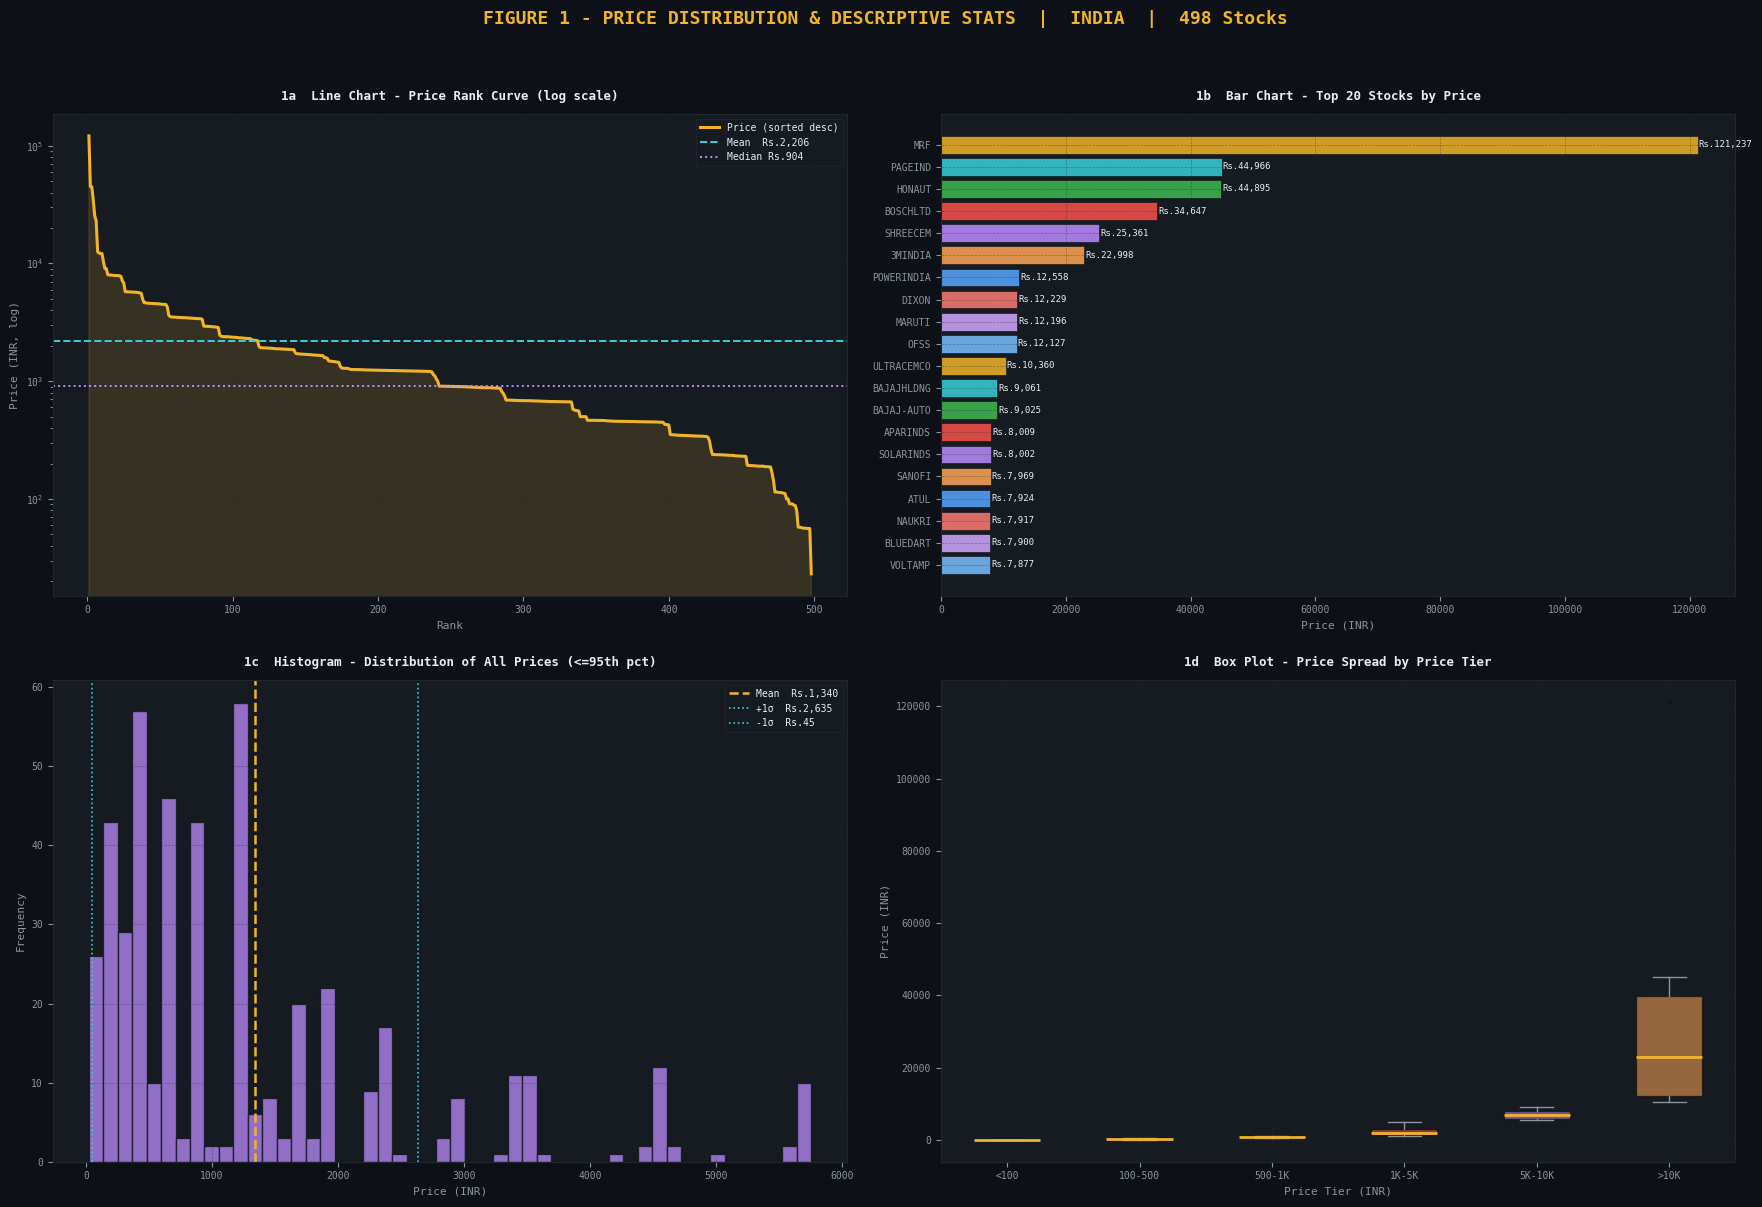

Saved: fig1_price_distribution_india.png


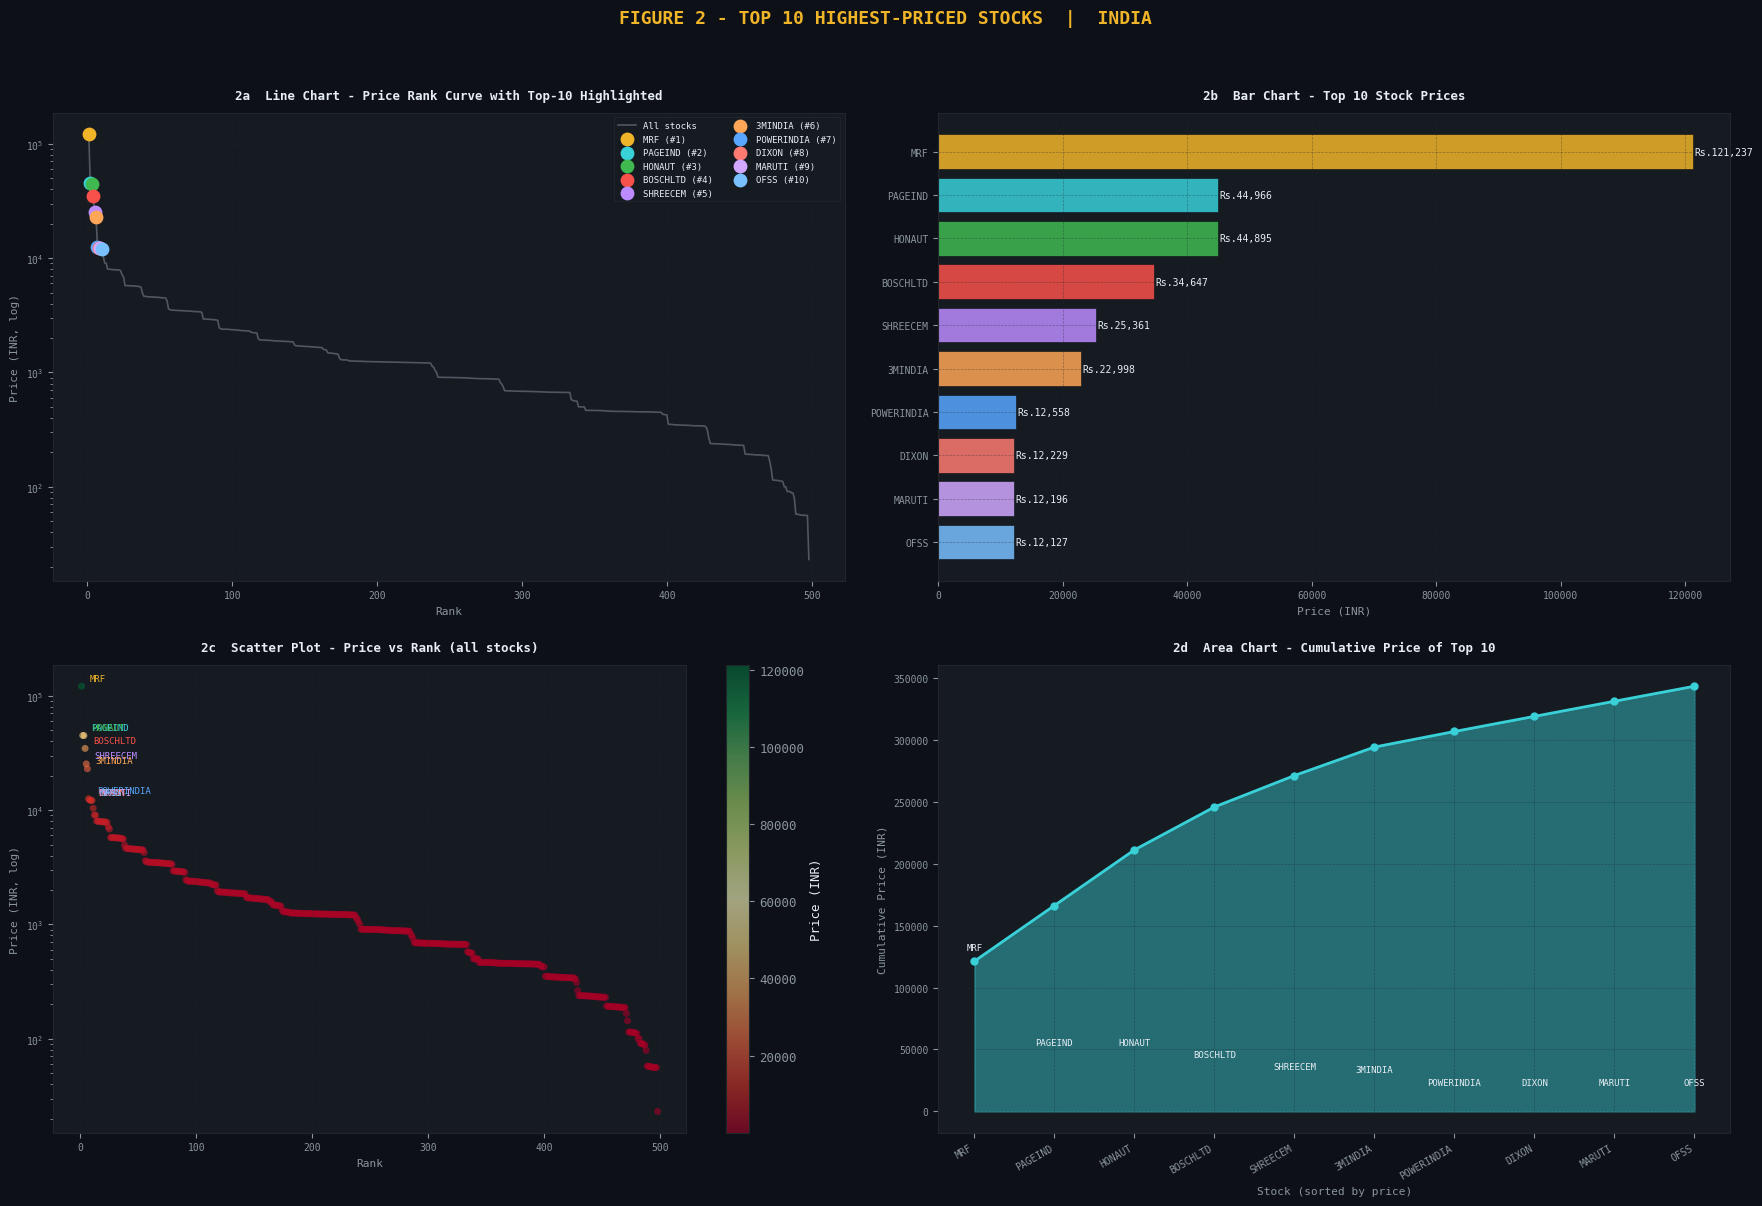

Saved: fig2_top10_india.png


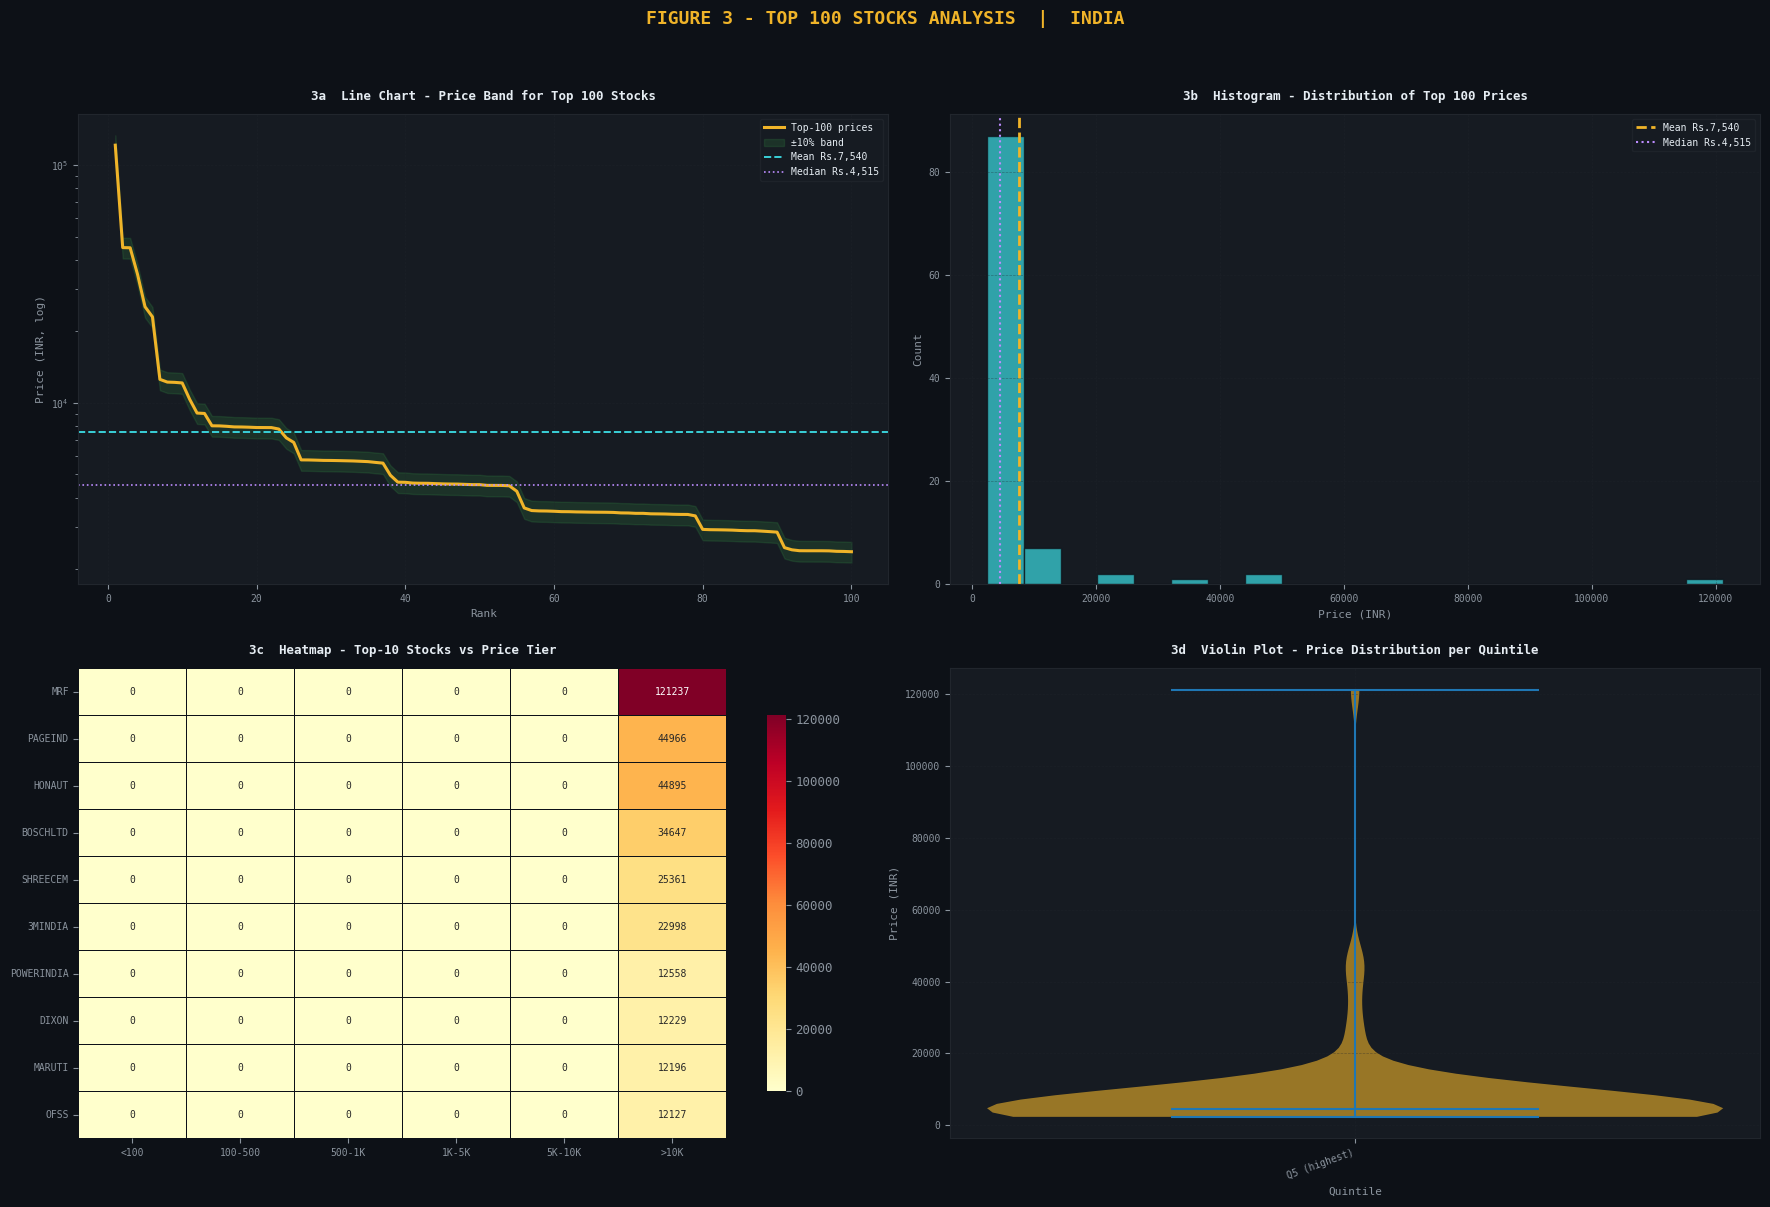

Saved: fig3_top100_india.png


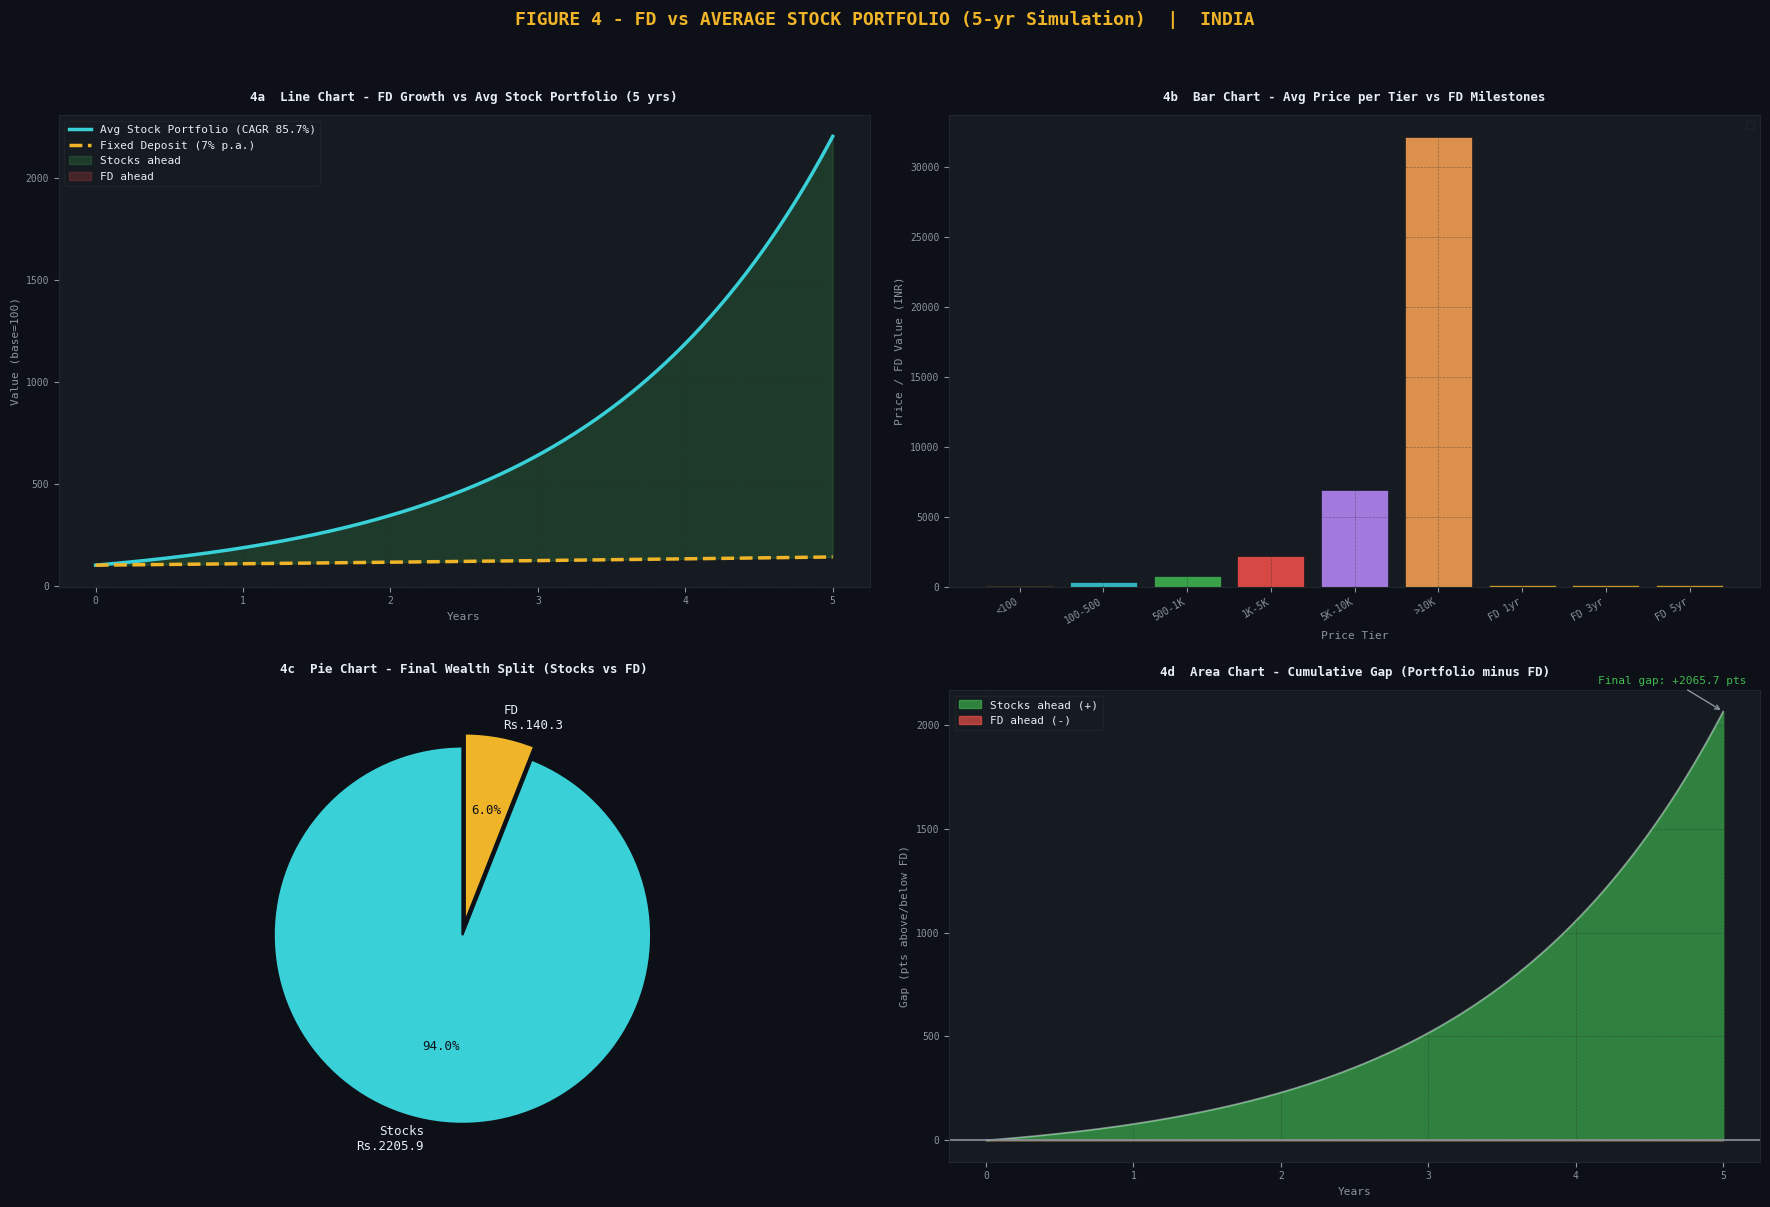

Saved: fig4_fd_vs_stocks_india.png


In [62]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

# ── Global dark theme ──────────────────────────────────────────────────────
DARK_BG  = '#0d1117'
PANEL_BG = '#161b22'
GOLD     = '#f0b429'
CYAN     = '#39d0d8'
GREEN    = '#3fb950'
RED      = '#f85149'
PURPLE   = '#bc8cff'
ORANGE   = '#ffa657'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
GRID     = '#21262d'

PALETTE_10 = [GOLD, CYAN, GREEN, RED, PURPLE, ORANGE,
              '#58a6ff', '#ff7b72', '#d2a8ff', '#79c0ff']

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor': PANEL_BG,
    'axes.edgecolor':   GRID,      'axes.labelcolor': TEXT,
    'axes.titlecolor':  TEXT,      'xtick.color': MUTED,
    'ytick.color':      MUTED,     'grid.color': GRID,
    'grid.linestyle':   '--',      'grid.linewidth': 0.5,
    'text.color':       TEXT,      'legend.facecolor': PANEL_BG,
    'legend.edgecolor': GRID,      'font.family': 'monospace',
    'font.size':        9,
})

def style_ax(ax, title, xlabel='', ylabel=''):
    ax.set_title(title, fontsize=9, pad=10, color=TEXT, fontweight='bold')
    if xlabel: ax.set_xlabel(xlabel, color=MUTED, fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color=MUTED, fontsize=8)
    ax.grid(True, alpha=0.4)
    ax.tick_params(labelsize=7)

print('Plot theme loaded.')

# ── FIGURE 1: Price Distribution & Descriptive Stats ──────────────────────
# Chart types: Line, Bar, Histogram, Box Plot

price_col = 'Price (INR)'
prices    = df[price_col].values
sorted_p  = np.sort(prices)[::-1]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=DARK_BG)
fig.suptitle(
    f'FIGURE 1 - PRICE DISTRIBUTION & DESCRIPTIVE STATS  |  INDIA  |  {len(df)} Stocks',
    fontsize=13, color=GOLD, fontweight='bold', y=1.01)
axes = axes.flatten()

# 1a. LINE CHART
ax = axes[0]
ranks = np.arange(1, len(sorted_p) + 1)
ax.plot(ranks, sorted_p, color=GOLD, lw=2.2, label='Price (sorted desc)')
ax.fill_between(ranks, sorted_p, alpha=0.15, color=GOLD)
ax.axhline(np.mean(prices),   color=CYAN,   lw=1.4, ls='--', label=f'Mean  Rs.{np.mean(prices):,.0f}')
ax.axhline(np.median(prices), color=PURPLE, lw=1.4, ls=':',  label=f'Median Rs.{np.median(prices):,.0f}')
ax.set_yscale('log')
ax.legend(fontsize=7, loc='upper right')
style_ax(ax, '1a  Line Chart - Price Rank Curve (log scale)', xlabel='Rank', ylabel='Price (INR, log)')

# 1b. BAR CHART
ax = axes[1]
top20 = df.nlargest(20, price_col)
bar_cols = [PALETTE_10[i % len(PALETTE_10)] for i in range(len(top20))]
bars = ax.barh(top20['Ticker'], top20[price_col], color=bar_cols, alpha=0.85, edgecolor=DARK_BG, lw=0.5)
for bar, val in zip(bars, top20[price_col]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2, f'Rs.{val:,.0f}', va='center', fontsize=6.5, color=TEXT)
ax.invert_yaxis()
style_ax(ax, '1b  Bar Chart - Top 20 Stocks by Price', xlabel='Price (INR)')

# 1c. HISTOGRAM
ax = axes[2]
clipped = prices[prices <= np.percentile(prices, 95)]
ax.hist(clipped, bins=50, color=PURPLE, alpha=0.75, edgecolor=DARK_BG, lw=0.3)
mu, sigma = float(np.mean(clipped)), float(np.std(clipped))
ax.axvline(mu,         color=GOLD, lw=1.8, ls='--', label=f'Mean  Rs.{mu:,.0f}')
ax.axvline(mu + sigma, color=CYAN, lw=1.2, ls=':',  label=f'+1σ  Rs.{mu+sigma:,.0f}')
ax.axvline(mu - sigma, color=CYAN, lw=1.2, ls=':',  label=f'-1σ  Rs.{mu-sigma:,.0f}')
ax.legend(fontsize=7)
style_ax(ax, '1c  Histogram - Distribution of All Prices (<=95th pct)', xlabel='Price (INR)', ylabel='Frequency')

# 1d. BOX PLOT
ax = axes[3]
tier_order = ['<100', '100-500', '500-1K', '1K-5K', '5K-10K', '>10K']
tier_data  = [df[df['Price Tier'] == t][price_col].values for t in tier_order]
tier_data  = [d for d in tier_data if len(d) > 0]
tier_lbls  = [t for t, d in zip(tier_order, [df[df['Price Tier'] == t][price_col].values for t in tier_order]) if len(d) > 0]
bp = ax.boxplot(tier_data, patch_artist=True,
                medianprops=dict(color=GOLD, lw=2),
                whiskerprops=dict(color=MUTED),
                capprops=dict(color=MUTED),
                flierprops=dict(marker='o', color=RED, alpha=0.3, markersize=2))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE_10[i % len(PALETTE_10)])
    patch.set_alpha(0.55)
ax.set_xticklabels(tier_lbls, fontsize=7)
style_ax(ax, '1d  Box Plot - Price Spread by Price Tier', xlabel='Price Tier (INR)', ylabel='Price (INR)')

plt.tight_layout(pad=2)
plt.savefig('fig1_price_distribution_india.png', dpi=140, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved: fig1_price_distribution_india.png')

# ── FIGURE 2: Top 10 Highest-Priced Stocks ────────────────────────────────
# Chart types: Line, Horizontal Bar, Scatter, Area

price_col = 'Price (INR)'
top10     = df.nlargest(10, price_col)
prices    = top10[price_col].values
tickers   = top10['Ticker'].tolist()
c10       = PALETTE_10[:len(tickers)]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=DARK_BG)
fig.suptitle('FIGURE 2 - TOP 10 HIGHEST-PRICED STOCKS  |  INDIA',
             fontsize=13, color=GOLD, fontweight='bold', y=1.01)
axes = axes.flatten()

# 2a. LINE CHART
ax = axes[0]
all_sorted = df.sort_values(price_col, ascending=False).reset_index(drop=True)
ax.plot(all_sorted.index + 1, all_sorted[price_col], color=MUTED, lw=1.2, alpha=0.5, label='All stocks')
for i, (_, row) in enumerate(top10.iterrows()):
    rank = all_sorted[all_sorted['Ticker'] == row['Ticker']].index[0] + 1
    ax.scatter(rank, row[price_col], color=c10[i], s=80, zorder=5, label=f"{row['Ticker']} (#{rank})")
ax.set_yscale('log')
ax.legend(fontsize=6.5, loc='upper right', ncol=2)
style_ax(ax, '2a  Line Chart - Price Rank Curve with Top-10 Highlighted', xlabel='Rank', ylabel='Price (INR, log)')

# 2b. HORIZONTAL BAR CHART
ax = axes[1]
sorted_top = top10.sort_values(price_col)
bars = ax.barh(sorted_top['Ticker'], sorted_top[price_col], color=c10[::-1], alpha=0.85, edgecolor=DARK_BG, lw=0.5)
for bar, val in zip(bars, sorted_top[price_col]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2, f'Rs.{val:,.0f}', va='center', ha='left', fontsize=7, color=TEXT)
style_ax(ax, '2b  Bar Chart - Top 10 Stock Prices', xlabel='Price (INR)')

# 2c. SCATTER PLOT
ax = axes[2]
all_sorted2 = df.sort_values(price_col, ascending=False).reset_index(drop=True)
sc = ax.scatter(all_sorted2.index + 1, all_sorted2[price_col],
                c=all_sorted2[price_col], cmap='RdYlGn', s=25, alpha=0.6, edgecolors='none')
for i, (_, row) in enumerate(top10.iterrows()):
    rank = all_sorted2[all_sorted2['Ticker'] == row['Ticker']].index[0] + 1
    ax.annotate(row['Ticker'], (rank, row[price_col]), textcoords='offset points', xytext=(6, 4), fontsize=6.5, color=c10[i])
plt.colorbar(sc, ax=ax, label='Price (INR)')
ax.set_yscale('log')
style_ax(ax, '2c  Scatter Plot - Price vs Rank (all stocks)', xlabel='Rank', ylabel='Price (INR, log)')

# 2d. AREA CHART
ax = axes[3]
sorted_top2 = top10.sort_values(price_col, ascending=False)
cum_prices  = sorted_top2[price_col].cumsum().values
x_pos       = np.arange(1, len(sorted_top2) + 1)
ax.fill_between(x_pos, cum_prices, color=CYAN, alpha=0.45, label='Cumulative Price')
ax.plot(x_pos, cum_prices, color=CYAN, lw=2, marker='o', markersize=5)
for xi, (_, row) in zip(x_pos, sorted_top2.iterrows()):
    ax.annotate(row['Ticker'], (xi, row[price_col]), textcoords='offset points', xytext=(0, 8), fontsize=6.5, color=TEXT, ha='center')
ax.set_xticks(x_pos)
ax.set_xticklabels(sorted_top2['Ticker'].tolist(), rotation=30, ha='right', fontsize=7)
style_ax(ax, '2d  Area Chart - Cumulative Price of Top 10', xlabel='Stock (sorted by price)', ylabel='Cumulative Price (INR)')

plt.tight_layout(pad=2)
plt.savefig('fig2_top10_india.png', dpi=140, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved: fig2_top10_india.png')

# ── FIGURE 3: Top 100 Stocks Analysis ─────────────────────────────────────
# Chart types: Line (band), Histogram, Heatmap, Violin

price_col = 'Price (INR)'
n         = min(100, len(df))
top_n     = df.nlargest(n, price_col).reset_index(drop=True)
prices    = top_n[price_col].values

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=DARK_BG)
fig.suptitle(f'FIGURE 3 - TOP {n} STOCKS ANALYSIS  |  INDIA',
             fontsize=13, color=GOLD, fontweight='bold', y=1.01)
axes = axes.flatten()

# 3a. LINE CHART - Price band
ax = axes[0]
ranks    = np.arange(1, n + 1)
sorted_p = np.sort(prices)[::-1]
ax.plot(ranks, sorted_p, color=GOLD, lw=2.2, label=f'Top-{n} prices')
ax.fill_between(ranks, sorted_p * 0.9, sorted_p * 1.1, color=GREEN, alpha=0.15, label='±10% band')
ax.axhline(np.mean(prices),   color=CYAN,   lw=1.4, ls='--', label=f'Mean Rs.{np.mean(prices):,.0f}')
ax.axhline(np.median(prices), color=PURPLE, lw=1.2, ls=':',  label=f'Median Rs.{np.median(prices):,.0f}')
ax.set_yscale('log')
ax.legend(fontsize=7, loc='upper right')
style_ax(ax, f'3a  Line Chart - Price Band for Top {n} Stocks', xlabel='Rank', ylabel='Price (INR, log)')

# 3b. HISTOGRAM
ax = axes[1]
n_bins = min(40, max(10, n // 5))
ax.hist(prices, bins=n_bins, color=CYAN, alpha=0.75, edgecolor=DARK_BG, lw=0.4)
ax.axvline(float(np.mean(prices)),   color=GOLD,   lw=2,   ls='--', label=f'Mean Rs.{np.mean(prices):,.0f}')
ax.axvline(float(np.median(prices)), color=PURPLE, lw=1.5, ls=':',  label=f'Median Rs.{np.median(prices):,.0f}')
ax.legend(fontsize=7)
style_ax(ax, f'3b  Histogram - Distribution of Top {n} Prices', xlabel='Price (INR)', ylabel='Count')

# 3c. HEATMAP
ax = axes[2]
tier_order = ['<100', '100-500', '500-1K', '1K-5K', '5K-10K', '>10K']
top10_tickers = df.nlargest(10, price_col)['Ticker'].tolist()
hm_data = pd.DataFrame(0, index=top10_tickers, columns=tier_order)
for tkr in top10_tickers:
    row = df[df['Ticker'] == tkr]
    if not row.empty:
        tier = str(row['Price Tier'].values[0])
        if tier in hm_data.columns:
            hm_data.loc[tkr, tier] = float(row[price_col].values[0])
sns.heatmap(hm_data, ax=ax, cmap='YlOrRd', linewidths=0.5,
            linecolor=DARK_BG, annot=True, fmt='.0f', annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('3c  Heatmap - Top-10 Stocks vs Price Tier', fontsize=9, color=TEXT, pad=10, fontweight='bold')
ax.tick_params(labelsize=7)

# 3d. VIOLIN PLOT
ax = axes[3]
quintile_order = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)']
violin_data = [top_n[top_n['price_quintile'] == q][price_col].values for q in quintile_order]
violin_data = [d for d in violin_data if len(d) > 1]
violin_lbls = [q for q, d in zip(quintile_order, [top_n[top_n['price_quintile'] == q][price_col].values for q in quintile_order]) if len(d) > 1]
if violin_data:
    parts = ax.violinplot(violin_data, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(PALETTE_10[i % len(PALETTE_10)])
        pc.set_alpha(0.6)
    ax.set_xticks(range(1, len(violin_lbls) + 1))
    ax.set_xticklabels(violin_lbls, rotation=20, ha='right', fontsize=7)
style_ax(ax, '3d  Violin Plot - Price Distribution per Quintile', xlabel='Quintile', ylabel='Price (INR)')

plt.tight_layout(pad=2)
plt.savefig('fig3_top100_india.png', dpi=140, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved: fig3_top100_india.png')

# ── FIGURE 4: FD vs Average Stock Portfolio (Simulated) ───────────────────
# Chart types: Line, Bar, Pie, Area

price_col = 'Price (INR)'
FD_RATE   = 0.07
CURRENCY  = 'Rs.'
prices    = df[price_col].values

avg_price   = float(np.mean(prices))
growth_rate = (avg_price / 100) ** (1 / 5) - 1
n_steps     = 500
t_axis      = np.linspace(0, 5, n_steps)
fd_line     = 100 * (1 + FD_RATE) ** t_axis
portfolio   = 100 * (1 + growth_rate) ** t_axis

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=DARK_BG)
fig.suptitle('FIGURE 4 - FD vs AVERAGE STOCK PORTFOLIO (5-yr Simulation)  |  INDIA',
             fontsize=13, color=GOLD, fontweight='bold', y=1.01)
axes = axes.flatten()

# 4a. LINE CHART
ax = axes[0]
ax.plot(t_axis, portfolio, color=CYAN,  lw=2.5, label=f'Avg Stock Portfolio (CAGR {growth_rate*100:.1f}%)')
ax.plot(t_axis, fd_line,   color=GOLD,  lw=2.5, ls='--', label=f'Fixed Deposit ({FD_RATE*100:.0f}% p.a.)')
ax.fill_between(t_axis, portfolio, fd_line, where=(portfolio >= fd_line), color=GREEN, alpha=0.2, label='Stocks ahead')
ax.fill_between(t_axis, portfolio, fd_line, where=(portfolio < fd_line),  color=RED,   alpha=0.2, label='FD ahead')
ax.legend(fontsize=8)
style_ax(ax, '4a  Line Chart - FD Growth vs Avg Stock Portfolio (5 yrs)', xlabel='Years', ylabel='Value (base=100)')

# 4b. BAR CHART
ax = axes[1]
tier_means = df.groupby('Price Tier', observed=True)[price_col].mean().dropna()
fd_vals    = {'FD 1yr': 100*(1+FD_RATE)**1, 'FD 3yr': 100*(1+FD_RATE)**3, 'FD 5yr': 100*(1+FD_RATE)**5}
all_labels = list(tier_means.index.astype(str)) + list(fd_vals.keys())
all_values = list(tier_means.values) + list(fd_vals.values())
bar_colors = [PALETTE_10[i % len(PALETTE_10)] for i in range(len(tier_means))] + [GOLD, GOLD, GOLD]
ax.bar(all_labels, all_values, color=bar_colors, alpha=0.85, edgecolor=DARK_BG, lw=0.5)
ax.set_xticklabels(all_labels, rotation=30, ha='right', fontsize=7)
ax.legend(fontsize=8)
style_ax(ax, '4b  Bar Chart - Avg Price per Tier vs FD Milestones', xlabel='Price Tier', ylabel='Price / FD Value (INR)')

# 4c. PIE CHART
ax = axes[2]
final_stock = portfolio[-1]
final_fd    = fd_line[-1]
pie_vals    = [final_stock, final_fd]
pie_labels  = [f'Stocks\n{CURRENCY}{final_stock:.1f}', f'FD\n{CURRENCY}{final_fd:.1f}']
wedges, texts, autotexts = ax.pie(
    pie_vals, labels=pie_labels, colors=[CYAN, GOLD],
    autopct='%1.1f%%', explode=(0.05, 0.02), startangle=90,
    textprops={'color': TEXT, 'fontsize': 9},
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 1.5})
for at in autotexts:
    at.set_fontsize(9); at.set_color(DARK_BG)
ax.set_title('4c  Pie Chart - Final Wealth Split (Stocks vs FD)', fontsize=9, color=TEXT, pad=12, fontweight='bold')

# 4d. AREA CHART
ax = axes[3]
gap     = portfolio - fd_line
pos_gap = np.where(gap >= 0, gap, 0)
neg_gap = np.where(gap < 0,  gap, 0)
ax.fill_between(t_axis, pos_gap, color=GREEN, alpha=0.65, label='Stocks ahead (+)')
ax.fill_between(t_axis, neg_gap, color=RED,   alpha=0.65, label='FD ahead (-)')
ax.plot(t_axis, gap, color=TEXT, lw=1.2, alpha=0.5)
ax.axhline(0, color=MUTED, lw=1.2)
final_gap = gap[-1]
ax.annotate(f'Final gap: {final_gap:+.1f} pts', xy=(t_axis[-1], final_gap),
            xytext=(-90, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color=MUTED),
            color=GREEN if final_gap >= 0 else RED, fontsize=8)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlabel('Years', color=MUTED, fontsize=8)
style_ax(ax, '4d  Area Chart - Cumulative Gap (Portfolio minus FD)', ylabel='Gap (pts above/below FD)')

plt.tight_layout(pad=2)
plt.savefig('fig4_fd_vs_stocks_india.png', dpi=140, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved: fig4_fd_vs_stocks_india.png')